In [75]:
import pandas as pd
# file_txt = pd.read_csv("C:/Users/USER/Downloads/STAT501_Lesson14/google_stock.txt")
# file_csv = file_txt.to_csv('google_stock.csv', '\t')
data = pd.read_csv('google_stock.csv')
data.head()

,date,price
0,2005/2/7,196.03
1,2005/2/8,198.64
2,2005/2/9,191.58
3,2005/2/10,187.98
4,2005/2/11,187.40


In [76]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

# 轉換日期欄位為datetime格式，並將日期設為索引
# data['date'] = pd.to_datetime(data['date'])
# data.set_index('date', inplace=True)
data

,date,price
0,2005/2/7,196.03
1,2005/2/8,198.64
2,2005/2/9,191.58
3,2005/2/10,187.98
4,2005/2/11,187.40
...,...,...
100,2005/6/30,294.15
101,2005/7/1,291.25
102,2005/7/5,295.71
103,2005/7/6,291.52


In [ ]:
# 提取價格作為時間序列資料
ts_data = data['price']
# 繪製PACF，修改樣式以接近Minitab風格
fig, ax = plt.subplots(figsize=(8, 5))
plot_pacf(ts_data, lags=26, ax=ax, method='ywm')  # 設定最大lag數
ax.axhline(y=0.2, color='red', linestyle='--')  # 信賴區間線
ax.axhline(y=-0.2, color='red', linestyle='--')
ax.set_xticks(range(0, 27, 2))  # X軸刻度從0開始，間隔2
ax.set_xlim(0, 27)  # 限制X軸的範圍為0到26
ax.set_title("Partial Autocorrelation Function for price", fontsize=12)
plt.show()


In [ ]:
import statsmodels.api as sm

# 創建滯後變數
data['lag5'] = data['price'].shift(5)
data['lag10'] = data['price'].shift(10)
data['lag15'] = data['price'].shift(15)

# 刪除缺失值
data = data.dropna()

# 定義應變項 (Y) 和自變項 (X)
Y = data['price']
X = data[['lag5', 'lag10', 'lag15']]
X = sm.add_constant(X)  # 加入常數項

# 建立回歸模型
model = sm.OLS(Y, X).fit()
model.summary()


In [ ]:
import statsmodels.api as sm

# 定義自變項和應變項
data['lag5'] = data['price'].shift(5)

# 刪除缺失值
data = data.dropna()

X = data[['lag5']]
X = sm.add_constant(X)  # 加入截距項
Y = data['price']

# 建立回歸模型
model = sm.OLS(Y, X).fit()
model.summary()


In [ ]:
data['lag1'] = data['price'].shift(1)

data = data.dropna()

# 定義新的回歸模型
X = data[['lag1']]
X = sm.add_constant(X)
Y = data['price']

model = sm.OLS(Y, X).fit()
print(model.summary())


In [ ]:
data['lag1'] = data['price'].shift(1)
data['lag2'] = data['price'].shift(2)
data['lag3'] = data['price'].shift(3)
data = data.dropna()

# 定義新的回歸模型
X = data[['lag1', 'lag2', 'lag3']]
X = sm.add_constant(X)
Y = data['price']

model = sm.OLS(Y, X).fit()
print(model.summary())


In [ ]:
# 提取殘差
residuals = model.resid
time_index = data.index  # 時間索引

# 繪製殘差對時間的散佈圖
plt.figure(figsize=(10, 6))
plt.plot(time_index, residuals, marker='o', linestyle='-', color='blue')
plt.axhline(y=0, color='red', linestyle='--')  # 添加基準線
plt.title("Residuals vs Time")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# 進行 Ljung-Box Q 檢定
result = acorr_ljungbox(residuals, lags=[10], return_df=True)
result

In [ ]:
# 計算 VIF
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

In [ ]:
import statsmodels.api as sm
data['lag1'] = data['price'].shift(1)
data['lag2'] = data['price'].shift(2)
data['lag3'] = data['price'].shift(3)
data = data.dropna()
# 1. 初始回歸模型
Y = data['price']
X = sm.add_constant(data[['lag1', 'lag2', 'lag3']])  # 添加截距
model = sm.OLS(Y, X).fit()
residuals = model.resid

# 2. 估算 rho
lag_residuals = residuals.shift(1).dropna()
rho = (residuals[1:] @ lag_residuals) / (lag_residuals @ lag_residuals)

# 3. 調整變數
Y_transformed = Y[1:] - rho * Y.shift(1)[1:]
X_transformed = X[1:] - rho * X.shift(1)[1:]

# 4. 重新回歸
model_cochrane_orcutt = sm.OLS(Y_transformed, X_transformed).fit()

# 5. 查看結果
print(model_cochrane_orcutt.summary())


ADF 檢定統計量: 0.5689332404612937
P-value: 0.9868243222254071


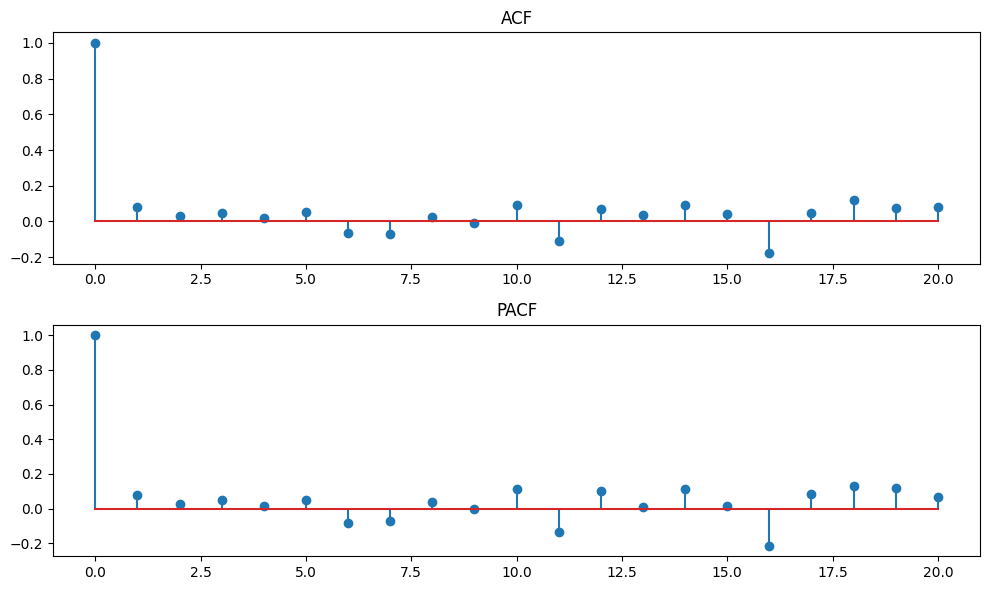

                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  105
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -302.558
Date:                Thu, 19 Dec 2024   AIC                            611.117
Time:                        16:03:22   BIC                            619.050
Sample:                             0   HQIC                           614.331
                                - 105                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9730      0.061     15.823      0.000       0.853       1.094
ma.L1         -0.9301      0.098     -9.467      0.000      -1.123      -0.738
sigma2        19.6558      2.181      9.012      0.0

In [77]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf

price = data['price']  # 假設價格列名為 'price'

# 平穩性檢測
result = adfuller(price)
print("ADF 檢定統計量:", result[0])
print("P-value:", result[1])

# 如果非平穩，進行差分
price_diff = price.diff().dropna()

# 繪製差分後的 ACF 和 PACF 圖
plt.figure(figsize=(10, 6))
plt.subplot(211)
plt.stem(acf(price_diff, nlags=20))
plt.title("ACF")
plt.subplot(212)
plt.stem(pacf(price_diff, nlags=20))
plt.title("PACF")
plt.tight_layout()
plt.show()

# 擬合 ARIMA(1,1,1)
model = ARIMA(price, order=(1, 1, 1))
arima_result = model.fit()
print(arima_result.summary())

# 預測未來值
forecast = arima_result.forecast(steps=10)
print("未來 10 期預測值:", forecast)
